In [ ]:
!pip install geopandas rasterio rasterstats shapely xarray rioxarray pyproj tqdm
!pip install scikit-learn imbalanced-learn xgboost lightgbm shap catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

WORK_DIR = "/content/drive/MyDrive/CropProject/"
!mkdir -p {WORK_DIR}

Mounted at /content/drive


## **climate data & Soil Feature Engineering**

In [ ]:
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import random
from shapely.geometry import Point
import seaborn as sns

**Download climate feature**

In [ ]:
!mkdir -p /content/data/worldclim/
!cp "/content/drive/MyDrive/CropProject/worldclim/wc2.1_2.5m_bio_1.tif" "/content/data/worldclim/bio1.tif"
!cp "/content/drive/MyDrive/CropProject/worldclim/wc2.1_2.5m_bio_12.tif" "/content/data/worldclim/bio12.tif"

**open, read and plots raster data (climate data)**

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


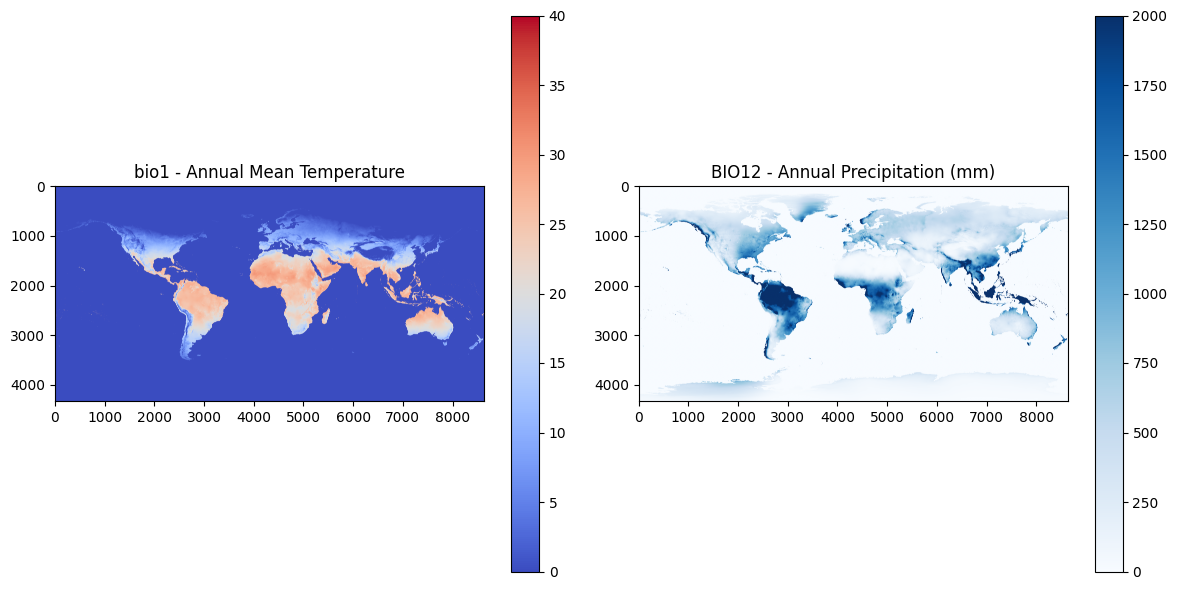

In [ ]:
bio1_path = "/content/data/worldclim/bio1.tif"    # Annual mean temperature
bio12_path = "/content/data/worldclim/bio12.tif"  # Annual precipitation

# open and read bio1
with rasterio.open(bio1_path) as src:
    bio1 = src.read(1)
    extent1 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]  # geographic extent of the raster

# open and read bio12
with rasterio.open(bio12_path) as src:
    bio12 = src.read(1)
    extent12 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Create fig with 2 colmns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot bio1 (temperature)
im1 = axes[0].imshow(bio1, cmap='coolwarm', vmin=0, vmax=40)
plt.colorbar(im1, ax=axes[0], orientation='vertical')
axes[0].set_title('bio1 - Annual Mean Temperature')

# Plot bio12 (rainfall)
im2 = axes[1].imshow(bio12, cmap='Blues', vmin=0, vmax=2000)
plt.colorbar(im2, ax=axes[1], orientation='vertical')
axes[1].set_title('BIO12 - Annual Precipitation (mm)')

plt.tight_layout()
plt.show()


**saudi Boundary Extraction & Visualization**

/tmp/ipython-input-3341886511.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = sa.geometry.unary_union # Merge all parts into a single shape


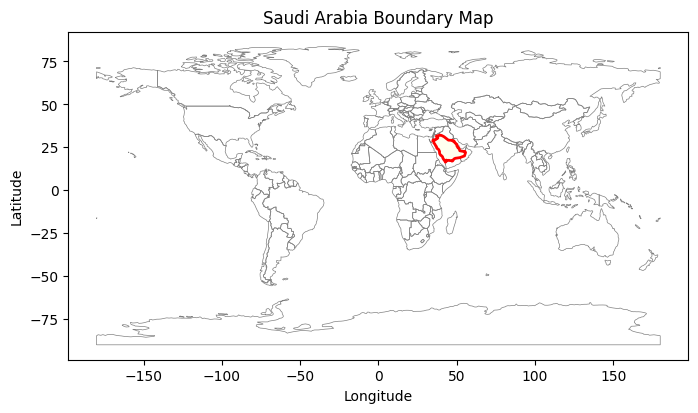

In [ ]:
# Load the global countries shape
shapefile_path = "/content/drive/MyDrive/CropProject/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)

sa = world[world['NAME'] == 'Saudi Arabia'].to_crs(epsg=4326) # Select Saudi Arabia
poly = sa.geometry.unary_union # Merge all parts into a single shape

# Visualization
fig, ax = plt.subplots(figsize=(8, 8))
world.boundary.plot(ax=ax, color='gray', linewidth=0.5) #boundaries of all countries
sa.boundary.plot(ax=ax, color='red', linewidth=2)  #boundary of Saudi Arabia
sa.plot(ax=ax, color='lightyellow', alpha=0.5) # Fill Saudi Arabia with yello color

ax.set_title("Saudi Arabia Boundary Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

**Random Sampling inside saudi**

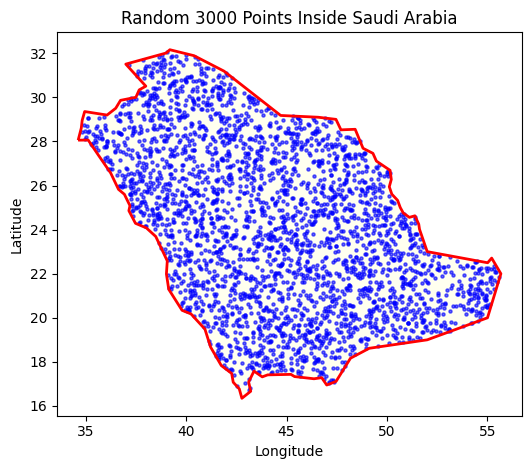

In [ ]:
import random
from shapely.geometry import Point

#generate random points
def sample_points(poly, n):
    minx, miny, maxx, maxy = poly.bounds  # polygon bounding
    pts = []      # List of accepted points
    tries = 0     # To avoid infinite loops

    while len(pts) < n and tries < n * 20:
        tries += 1
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)

        # Check if the point is accepted
        if poly.contains(p):
            pts.append({"lon": x, "lat": y})

    return pd.DataFrame(pts)


df = sample_points(poly, 3000)
df.to_csv(WORK_DIR + "sa_samples.csv", index=False)

#Visualization
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Saudi
sa.plot(ax=ax, color='lightyellow', alpha=0.5)
sa.boundary.plot(ax=ax, color='red', linewidth=2)

# Plot points
plt.scatter(df["lon"], df["lat"], s=5, alpha=0.6, color="blue")

ax.set_title("Random 3000 Points Inside Saudi Arabia")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

**Climate raster Value Extraction**

In [ ]:

def sample_raster(tif_path, points_df, band=1):
    values = []

    with rasterio.open(tif_path) as src:
        raster_band = src.read(band)

        for lon, lat in zip(points_df['lon'], points_df['lat']):
            try:
                row, col = src.index(lon, lat) # Convert lon/lat to raster row/col indices
                val = raster_band[row, col] # Extract value at that pixel

            except:
                val = np.nan # If point is outside raster bounds

            values.append(val)

    return values

# Load the previously generated points
df = pd.read_csv(WORK_DIR + "sa_samples.csv")

# Extract climate data
df['bio1'] = sample_raster("/content/data/worldclim/bio1.tif", df)
df['bio12'] = sample_raster("/content/data/worldclim/bio12.tif", df)

df.head()

,lon,lat,bio1,bio12
0,47.262268,25.409696,25.507168,125.0
1,38.081215,30.272728,21.028833,38.0
2,40.757856,20.760121,20.066166,205.0
3,50.349408,20.724032,28.738501,58.0
4,47.992909,21.245723,28.972334,67.0


**Download soil feature**

In [ ]:
!mkdir -p /content/data/soil/
!cp "/content/drive/MyDrive/CropProject/soil/ph.tif" "/content/data/soil/ph.tif"
!cp "/content/drive/MyDrive/CropProject/soil/sand.tif" "/content/data/soil/sand.tif"
!cp "/content/drive/MyDrive/CropProject/soil/clay.tif" "/content/data/soil/clay.tif"
!cp "/content/drive/MyDrive/CropProject/soil/silt.tif" "/content/data/soil/silt.tif"
!cp "/content/drive/MyDrive/CropProject/soil/soc.tif" "/content/data/soil/soc.tif"

**Soil Raster Integrity Verification**

In [ ]:
soil_files = {
    "ph": "/content/data/soil/ph.tif",
    "sand": "/content/data/soil/sand.tif",
    "silt": "/content/data/soil/silt.tif",
    "clay": "/content/data/soil/clay.tif",
    "soc": "/content/data/soil/soc.tif"
}

for layer, file_path in soil_files.items():
    try:
        with rasterio.open(file_path) as src:
            print(f"{layer.upper()} file opened successfully!")
            print(f"Dimensions: {src.width} x {src.height}")
            print(f"Bounds: {src.bounds}")

            # Extract 200 example values to inspect data soundness
            sample_vals = src.read(1).flatten()[100:300]
            print(f"Sample values (100–300): {sample_vals}")

            print("-" * 40)

    except Exception as e:
        print(f"Error opening {layer}: {e}")


PH file opened successfully!
Dimensions: 9378 x 6778
Bounds: BoundingBox(left=34.5, bottom=16.0, right=55.70000000000001, top=32.2)
Sample values (100–300): [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 76 75 75  0  0 75 75 75 75
 75 75 76 76 75 75 74 74 73 76 76 76 76 74 74 76 74 74  0  0  0  0  0 76
 76 75 75 74 75 74 74 75 75 75 76 75 76 76 76 75 75 76 76 74 74 75 73 73
 73 74 75 75 75 76 76 75 75 75 75 75  0 76 74 75 75 75 76 76 74 76 77 77
 77 77 77 77 77 77 77 77 77 76 76 77 77 77 77 77  0 77 77 77 78 78 77 77
 77 77 77 77 77 78 77 78 78 78 78 78 78 78 77 77 77 77 77 77 77 77 77 77
 77 77 77 77 77 77 77 77 77 77 77 77 77 77 76 76 77 76 76 77 77 77 77 76
 76 76 76 77 77 76 76 76]
----------------------------------------
SAND file opened successfully!
Dimensions: 9378 x 6778
Bounds: BoundingBox(left=34.5, bottom=16.0, right=55.70000000000001, top=32.2)
Sample values (100–300): [  0   0   0   0   0   0   0   0 

**Soil Raster Layer Visualization**

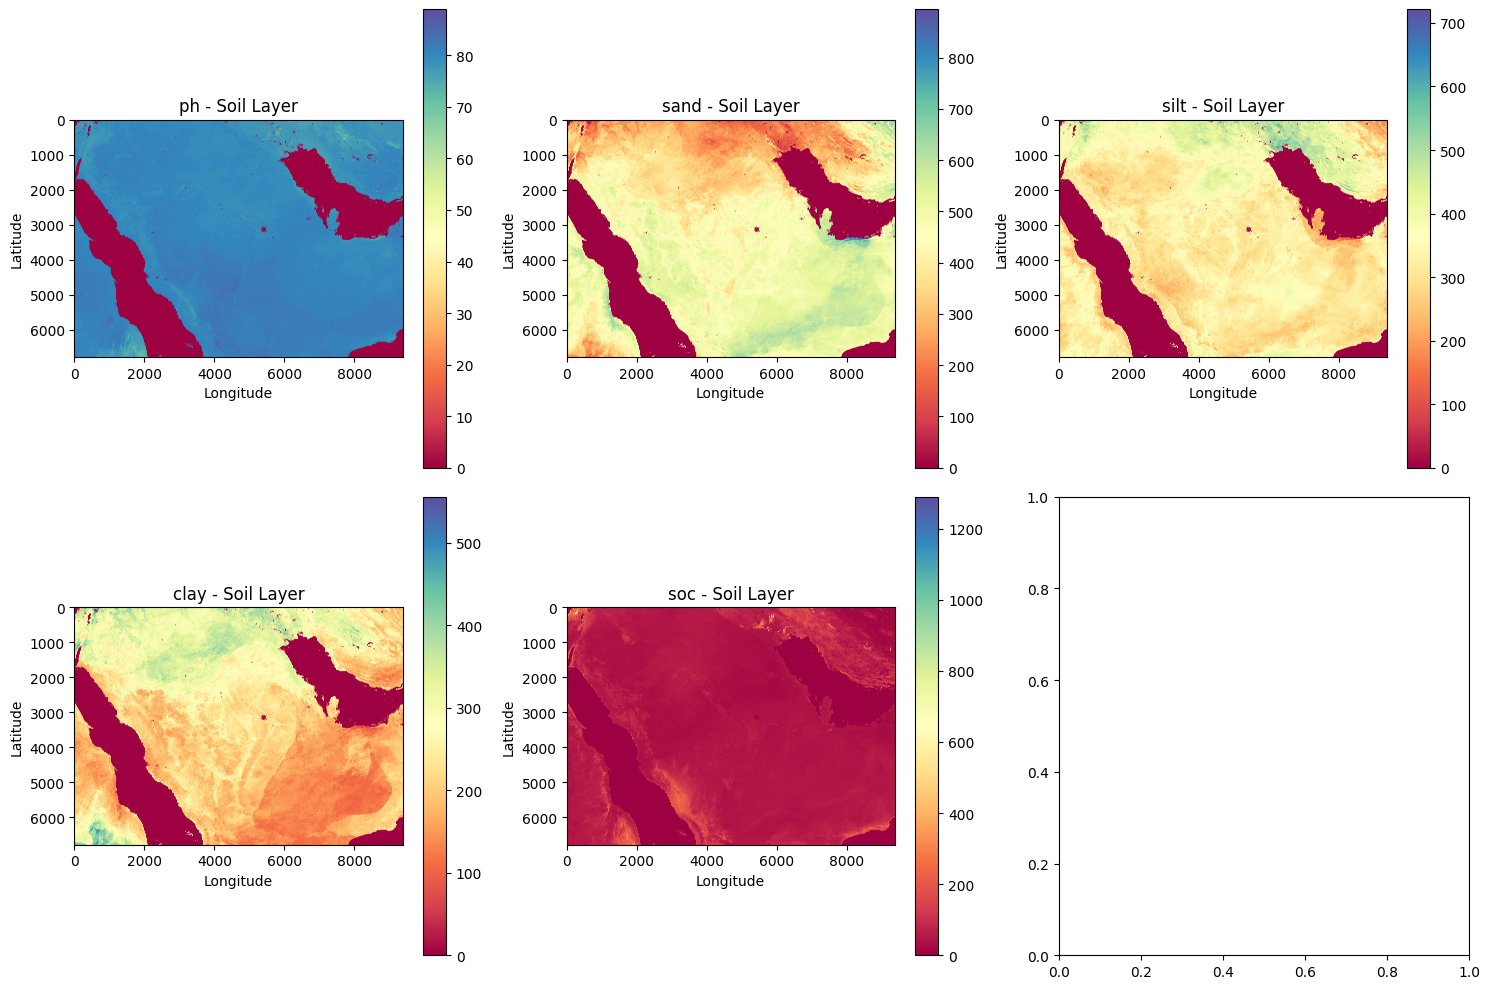

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i, (layer, file_path) in enumerate(soil_files.items()):
    ax = axes[i // 3, i % 3] # Select subplot position

    with rasterio.open(file_path) as src:
        data = src.read(1)
        im = ax.imshow(data, cmap='Spectral', vmin=data.min(), vmax=data.max())

        ax.set_title(f'{layer} - Soil Layer')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.colorbar(im, ax=ax) # Add color scale

plt.tight_layout()
plt.show()


**soil raster Value Extraction**

In [ ]:
df['ph']   = sample_raster("/content/data/soil/ph.tif", df)
df['sand'] = sample_raster("/content/data/soil/sand.tif", df)
df['silt'] = sample_raster("/content/data/soil/silt.tif", df)
df['clay'] = sample_raster("/content/data/soil/clay.tif", df)
df['soc']  = sample_raster("/content/data/soil/soc.tif", df)

print(df.head(10))

         lon        lat       bio1  bio12  ph  sand  silt  clay  soc
0  47.262268  25.409696  25.507168  125.0  79   436   323   242   59
1  38.081215  30.272728  21.028833   38.0  81   322   336   342   63
2  40.757856  20.760121  20.066166  205.0  78   527   226   247  164
3  50.349408  20.724032  28.738501   58.0  80   529   342   129   50
4  47.992909  21.245723  28.972334   67.0  81   493   342   165   47
5  42.675626  26.357843  23.433666  173.0  80   447   314   239   43
6  45.622646  20.579213  28.835501   88.0  81   466   324   210   43
7  39.587995  29.131737  21.449167   69.0  80   351   313   336   39
8  49.489298  22.752242  28.155333   64.0  80   476   375   149   46
9  45.508844  23.343079  26.760166  122.0  81   434   328   238   48


**Crop Environmental Suitability Thresholds**

In [ ]:
# Each crop has: (min, low_opt, high_opt, max)

CROP_REQ = {
    "date_palm": {
        "bio1":  (26, 28, 31, 32),     # Very high temperature
        "bio12": (0,  5,  80, 120),    # Extremely low rainfall
        "ph":    (77, 79, 83, 84),  "sand":(380, 450, 620, 660), "clay":(0,   80, 220, 260), "soc":(0,   10, 60, 90)},

    # 2) Wheat – prefers colder & wetter conditions
    "wheat": {
        "bio1": (17, 19, 24, 27),"bio12": (100, 140, 220, 280),"ph":(65, 70, 80, 82), "sand": (300, 380, 520, 580),
        "clay": (160, 200, 270, 320), "soc":(30,  50, 140, 200) },

    # 3) Sorghum – hot & semi-arid crop
    "sorghum": {
        "bio1":(22, 24, 28.5, 31), "bio12": (60,  90, 180, 240), "ph":(68, 72, 80, 83), "sand": (340, 420, 580, 640),
        "clay":(150, 190, 260, 320), "soc": (25,  40, 120, 180)},

    # 4) Alfalfa – likes better SOC
    "alfalfa": {
        "bio1":(18, 20, 26, 29), "bio12": (80,  110, 220, 260), "ph":(65,  70, 78, 82), "sand":(280, 360, 520, 600),
        "clay":(170, 210, 280, 330), "soc":   (40,  60, 160, 220) },
}

**find the target by Crop Suitability Scoring System**

In [ ]:
# Calculates a suitability score for a single feature based on range

def score_range(value, acceptable_range):
    if np.isnan(value):
        return np.nan

    mn, opt_min, opt_max, mx = acceptable_range

    if value < mn or value > mx:  # Outside the allowed range
        return 0.0

    if opt_min <= value <= opt_max: # Inside the optimal range
        return 1.0

    if value < opt_min: # If the value is between lower and optimal =
        return (value - mn) / (opt_min - mn)

    return (mx - value) / (mx - opt_max) # If the value is between optimal and upper


# Computes suitability for all crops for ONE row
# Returns a dictionary: { "wheat":0.73, "alfalfa":0.55, ... }
def suitability_scores(row, crop_req):
    scores = {}
    for crop, req in crop_req.items():
        scs = [score_range(row[feat], rng) for feat, rng in req.items()]
        scores[crop] = np.nanmean(scs)   # Mean suitability for that crop
    return scores

# Apply suitability scoring to the all entire DataFrame
scores_list = df.apply( lambda r: suitability_scores(r, CROP_REQ), axis=1) #axis=1 > row
scores_df = pd.DataFrame(scores_list.tolist())

# Add column with the best crop (max) for each point
df["best_crop"] = scores_df.idxmax(axis=1)

## **cleaning data**

**Outliers Detection**

In [ ]:
print(df.shape)
print(df.isna().sum())

(3000, 10)
lon          0
lat          0
bio1         0
bio12        0
ph           0
sand         0
silt         0
clay         0
soc          0
best_crop    0
dtype: int64


In [ ]:
print(df[['bio1', 'bio12']].describe())
print(df[['sand', 'silt', 'clay', 'ph', 'soc']].describe())

               bio1         bio12
count  3.000000e+03  3.000000e+03
mean           -inf          -inf
std             inf           inf
min   -3.400000e+38 -3.400000e+38
25%    2.401846e+01  6.900000e+01
50%    2.614250e+01  9.300000e+01
75%    2.819163e+01  1.280000e+02
max    3.080850e+01  2.590000e+02
              sand         silt         clay           ph          soc
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000
mean    451.068333   321.523000   221.078667    79.911667    49.963000
std      85.292563    45.327611    66.177476     6.484434    25.635744
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%     397.000000   299.000000   173.000000    80.000000    38.000000
50%     468.000000   321.000000   214.000000    80.000000    45.000000
75%     511.000000   345.000000   264.000000    81.000000    52.000000
max     643.000000   485.000000   411.000000    84.000000   287.000000


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)


min   = -3.4e+38  = no data

In [ ]:
#Fix values
df['bio1']  = df['bio1'].mask((df['bio1'] < -30) | (df['bio1'] > 60), np.nan)
df['bio12'] = df['bio12'].mask((df['bio12'] < 0)   | (df['bio12'] > 4000), np.nan)

print(df[['bio1','bio12']].describe())

              bio1        bio12
count  2994.000000  2994.000000
mean     25.835836   103.304947
std       2.717360    44.319851
min      17.634167     5.000000
25%      24.041792    69.000000
50%      26.149666    93.000000
75%      28.197250   128.000000
max      30.808500   259.000000


In [ ]:
df[['bio1','bio12']].isna().sum()

,0
bio1,6
bio12,6


In [ ]:
zero_soil = (df[['ph','sand','silt','clay','soc']] == 0).all(axis=1)
print(zero_soil.sum())
df[zero_soil].head()

19


,lon,lat,bio1,bio12,ph,sand,silt,clay,soc,best_crop
215,42.548159,16.901342,25.654167,106.0,0,0,0,0,0,sorghum
218,41.187933,18.826319,NaN,NaN,0,0,0,0,0,date_palm
417,38.661640,23.398175,27.806250,67.0,0,0,0,0,0,date_palm
603,50.073741,26.436045,26.386333,77.0,0,0,0,0,0,sorghum
966,37.909990,26.684904,22.566833,66.0,0,0,0,0,0,date_palm


In [ ]:
clean = df.copy()
clean = clean[~zero_soil].copy()
print(clean.shape)

(2981, 10)


In [ ]:
clean[['bio1','bio12']].isna().sum()

,0
bio1,0
bio12,0


In [ ]:
print(clean["best_crop"].value_counts())

best_crop
sorghum      1195
date_palm    1130
wheat         451
alfalfa       205
Name: count, dtype: int64


## **Exploratory Data Analysis (EDA)**

**Target Distribution (Countplot)**

The countplot shows the class is imbalance
This imbalance increases the risk of biased predictions and requires:


*   Class weighting
*   Oversampling / undersampling techniques

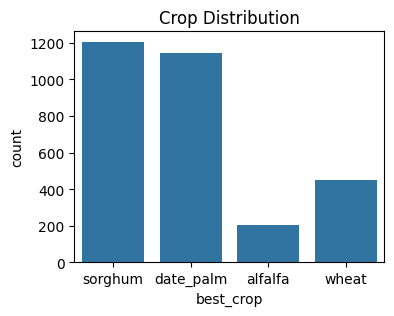

In [ ]:
plt.figure(figsize=(4,3))
target_col = 'best_crop'
sns.countplot(data=df, x=target_col)
plt.title("Crop Distribution")
plt.show()

**Pairplot**

Pairplots illustrate pairwise relationships.
Highly overlapping clusters signal that the classification task is more complex.

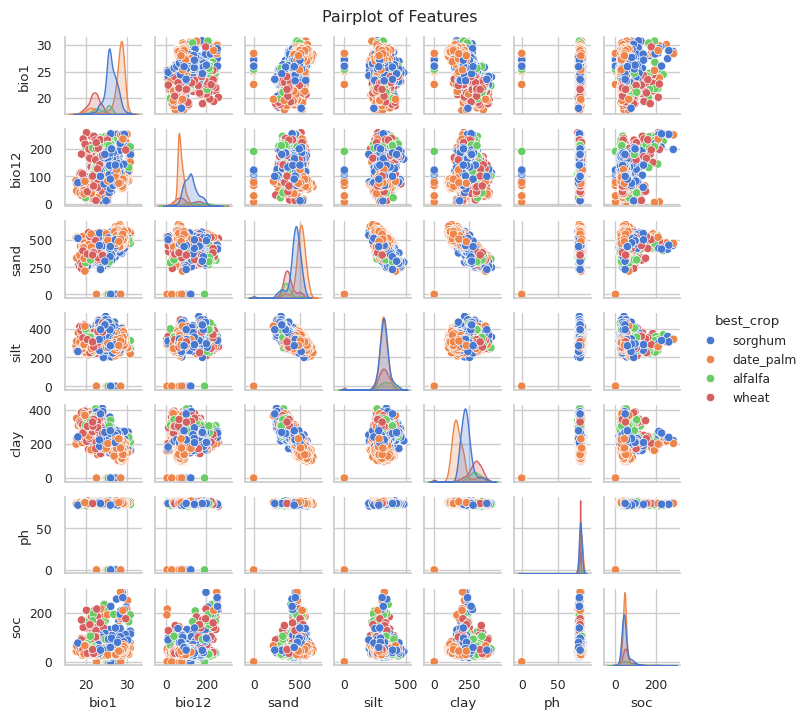

In [ ]:

sns.set(style="whitegrid", palette="muted", font_scale=0.8)

num_cols = ['bio1','bio12','sand', 'silt', 'clay', 'ph', 'soc']
target_col = 'best_crop'

sns.pairplot(df[num_cols + [target_col]], hue=target_col, height=1.0)
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()


**Correlation Heatmap**

it clearly shows that there are no strong linear correlations between most features.
This implies:

*   Low multicollinearity
*   Linear models will likely perform poorly

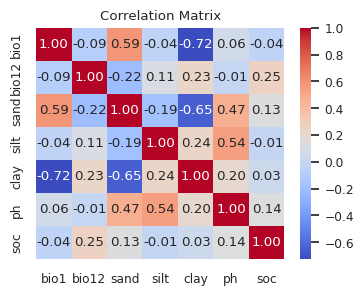

In [ ]:
plt.figure(figsize=(4,3))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
